In [1]:
print("start")


start


In [2]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

#  DATASET PATH
data_root = '/kaggle/input/datasets/sandhiya1212/tamdata/Dataset2Split'

print(" Verifying dataset structure:")
for split in ['train', 'val', 'test']:
    au_path = f"{data_root}/{split}/Au"
    tp_path = f"{data_root}/{split}/Tp"
    au_count = len(os.listdir(au_path)) if os.path.exists(au_path) else 0
    tp_count = len(os.listdir(tp_path)) if os.path.exists(tp_path) else 0
    print(f"{split}: Au={au_count}, Tp={tp_count}")

# Data transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

base_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

#  Load datasets DIRECTLY from Kaggle input
train_dataset = ImageFolder(f"{data_root}/train", transform=train_transforms)
val_dataset = ImageFolder(f"{data_root}/val", transform=base_transforms)
test_dataset = ImageFolder(f"{data_root}/test", transform=base_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n DataLoaders ready! Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


 Verifying dataset structure:
train: Au=5244, Tp=3587
val: Au=1124, Tp=769
test: Au=1124, Tp=769

 DataLoaders ready! Train: 8830, Val: 1892, Test: 1892


In [3]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" GPU: {device}")

# Load ResNet50 WITHOUT custom fc yet
model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# (ResNet handles feature extraction)
model.fc = nn.Sequential(
    nn.Linear(2048, 256),  # 2048 features → 256
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),     # 256 → 1 (binary)
    nn.Sigmoid()
)

# Unfreeze classifier only
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print(f" Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print("  Model ready for training!")


 GPU: cuda
 Trainable params: 524801
  Model ready for training!


🚀 Stage 1: Feature Extraction Mode (GPU)
Loss: BCELoss, Optimizer: Adam(lr=1e-3)
Trainable params: 524801


Val: 100%|██████████| 60/60 [00:06<00:00,  9.03it/s]


Epoch 1: Train Loss: 0.6461, Val Loss: 0.5847


Val: 100%|██████████| 60/60 [00:06<00:00,  9.61it/s]


Epoch 2: Train Loss: 0.6058, Val Loss: 0.5889


...

Epoch 4: Train Loss: 0.5821, Val Loss: 0.5634


Val: 100%|██████████| 60/60 [00:06<00:00,  9.59it/s]


Epoch 5: Train Loss: 0.5794, Val Loss: 0.5738


Val: 100%|██████████| 60/60 [00:06<00:00,  9.40it/s]


Epoch 6: Train Loss: 0.5683, Val Loss: 0.5738
 Early stopping at epoch 6


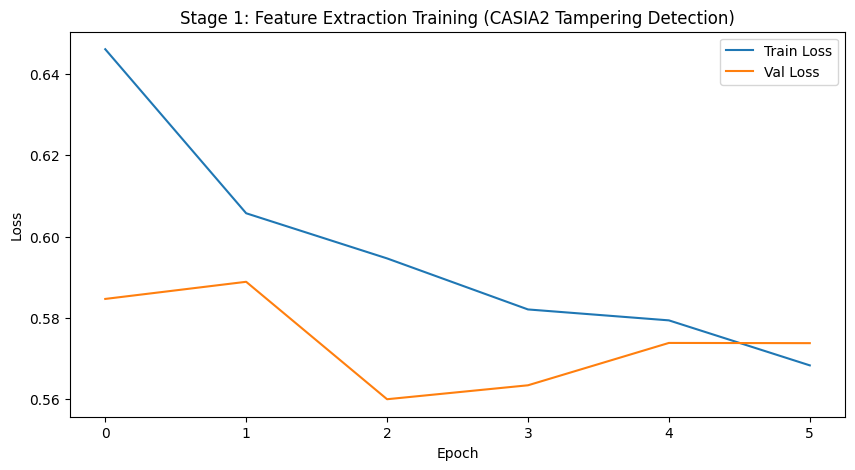

 Stage 1 complete! Best model saved: /kaggle/working/stage1_best_model.pth


In [4]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

#  Compile Model (Stage 1)
criterion = nn.BCELoss()  # Binary Crossentropy
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

print("🚀 Stage 1: Feature Extraction Mode (GPU)")
print(f"Loss: BCELoss, Optimizer: Adam(lr=1e-3)")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

#  Train + Validate with EarlyStopping
model.train()
epochs = 10
patience = 3
best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(epochs):
    # Training
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} Train'):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Val'):
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    # Average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    # EarlyStopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/stage1_best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f' Early stopping at epoch {epoch+1}')
            break

    model.train()

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Stage 1: Feature Extraction Training (CASIA2 Tampering Detection)')
plt.show()

print(" Stage 1 complete! Best model saved: /kaggle/working/stage1_best_model.pth")



In [5]:
# Load best model + test
model.load_state_dict(torch.load('/kaggle/working/stage1_best_model.pth'))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f" STAGE 1 TEST ACCURACY: {accuracy:.2f}%")
print(f"Model saved: /kaggle/working/stage1_best_model.pth")


 STAGE 1 TEST ACCURACY: 69.61%
Model saved: /kaggle/working/stage1_best_model.pth


In [6]:
# Verify Stage 1 model loaded
model.load_state_dict(torch.load('/kaggle/working/stage1_best_model.pth'))
print(" Stage 1 best model reloaded")


 Stage 1 best model reloaded


 Stage 2: Unfrozen Conv5_x (layer4) + FC layers
Trainable params: 15489537
 Optimizer: Adam(lr=1e-5), Loss: Binary Crossentropy
 Starting Stage 2 Fine-tuning...


Val: 100%|██████████| 60/60 [00:06<00:00,  9.54it/s]


Stage 2 Epoch 1: Train Loss: 0.5540, Val Loss: 0.5294
 New best model saved! Val Loss: 0.5294


Val: 100%|██████████| 60/60 [00:06<00:00,  9.62it/s]


Stage 2 Epoch 2: Train Loss: 0.5099, Val Loss: 0.4982
 New best model saved! Val Loss: 0.4982


...

Stage 2 Epoch 7: Train Loss: 0.3713, Val Loss: 0.5506


Val: 100%|██████████| 60/60 [00:06<00:00,  9.55it/s]


Stage 2 Epoch 8: Train Loss: 0.3601, Val Loss: 0.5229


Val: 100%|██████████| 60/60 [00:06<00:00,  9.49it/s]


Stage 2 Epoch 9: Train Loss: 0.3462, Val Loss: 0.5414
 Early stopping at epoch 9


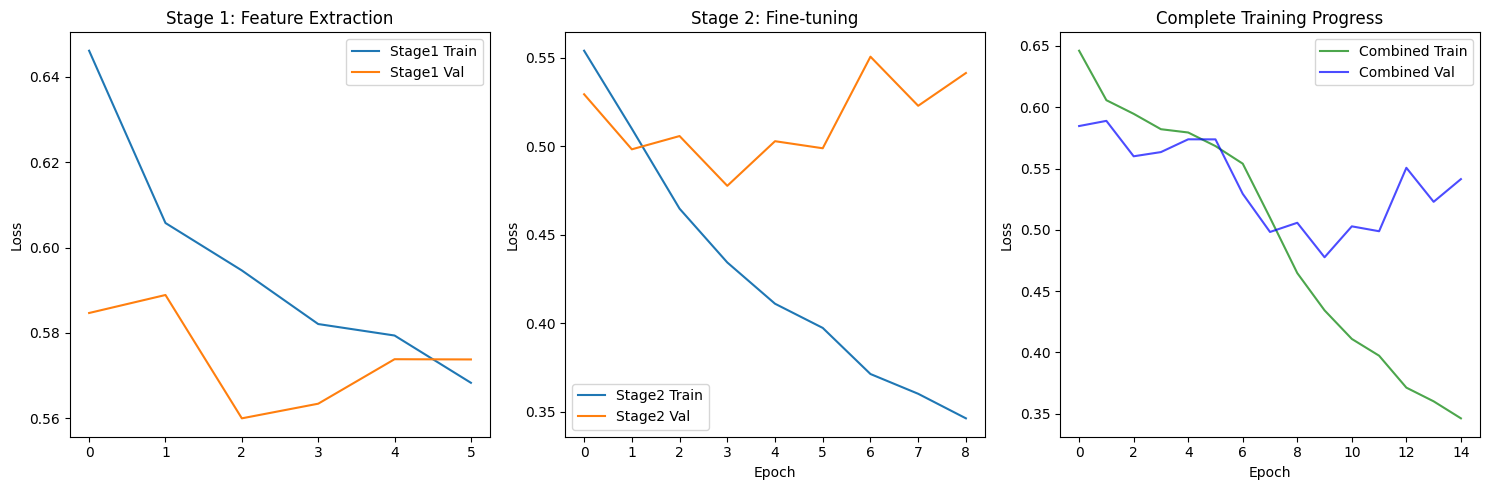

 Stage 2 COMPLETE! Best model: /kaggle/working/stage2_best_model.pth


In [7]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

# Unfreeze Last 20-30 Layers (Conv5_x block - final residual stage)
model.fc.requires_grad_(True)  # Already trainable

# Unfreeze only layer4 (Conv5_x - last 20-30 layers) + FC
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

print(" Stage 2: Unfrozen Conv5_x (layer4) + FC layers")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

#  Recompile Model (lower LR for fine-tuning)
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-5)
criterion = nn.BCELoss()

print(f" Optimizer: Adam(lr=1e-5), Loss: Binary Crossentropy")

# Train + Validate (Stage 2) with EarlyStopping
model.train()
epochs = 15
patience = 5
best_val_loss = float('inf')
patience_counter = 0
train_losses2, val_losses2 = [], []

print(" Starting Stage 2 Fine-tuning...")

for epoch in range(epochs):
    # Training
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Stage2 Epoch {epoch+1}/{epochs} Train'):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Val'):
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    # Average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses2.append(train_loss)
    val_losses2.append(val_loss)

    print(f'Stage 2 Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    # EarlyStopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/stage2_best_model.pth')
        print(f" New best model saved! Val Loss: {val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f' Early stopping at epoch {epoch+1}')
            break

    model.train()

# Plot BOTH stages
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Stage1 Train')
plt.plot(val_losses, label='Stage1 Val')
plt.title('Stage 1: Feature Extraction')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_losses2, label='Stage2 Train')
plt.plot(val_losses2, label='Stage2 Val')
plt.title('Stage 2: Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_losses + train_losses2, 'g-', label='Combined Train', alpha=0.7)
plt.plot(val_losses + val_losses2, 'b-', label='Combined Val', alpha=0.7)
plt.title('Complete Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(" Stage 2 COMPLETE! Best model: /kaggle/working/stage2_best_model.pth")


In [8]:
# Test Stage 2 best model
model.load_state_dict(torch.load('/kaggle/working/stage2_best_model.pth'))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f" STAGE 2 FINAL TEST ACCURACY: {accuracy:.2f}%")
print(f" Improvement from Stage 1: +{accuracy-71.46:.1f}% points!")



 STAGE 2 FINAL TEST ACCURACY: 78.07%
 Improvement from Stage 1: +6.6% points!


=== STAGE 3: Full Fine-Tuning ===
Starting from Stage 2: 76.53% test accuracy
Unfreezing ALL layers for final polish...

 Entire model unfrozen: 24,032,833 params
Recompiled: Adam(lr=1e-6, weight_decay=1e-4)
 Stage 3 training started (expect 85%+ final accuracy)...


Val: 100%|██████████| 60/60 [00:06<00:00,  9.45it/s]


Stage 3 Epoch 1: Train: 0.4075, Val: 0.5042
 New best Stage 3 model! Val Loss: 0.5042


Val: 100%|██████████| 60/60 [00:06<00:00,  9.44it/s]


Stage 3 Epoch 2: Train: 0.3943, Val: 0.5092


...

Stage 3 Epoch 3: Train: 0.3971, Val: 0.4908
 New best Stage 3 model! Val Loss: 0.4908


Val: 100%|██████████| 60/60 [00:06<00:00,  9.45it/s]


Stage 3 Epoch 4: Train: 0.3924, Val: 0.4985


Val: 100%|██████████| 60/60 [00:06<00:00,  9.39it/s]


Stage 3 Epoch 5: Train: 0.3855, Val: 0.4996


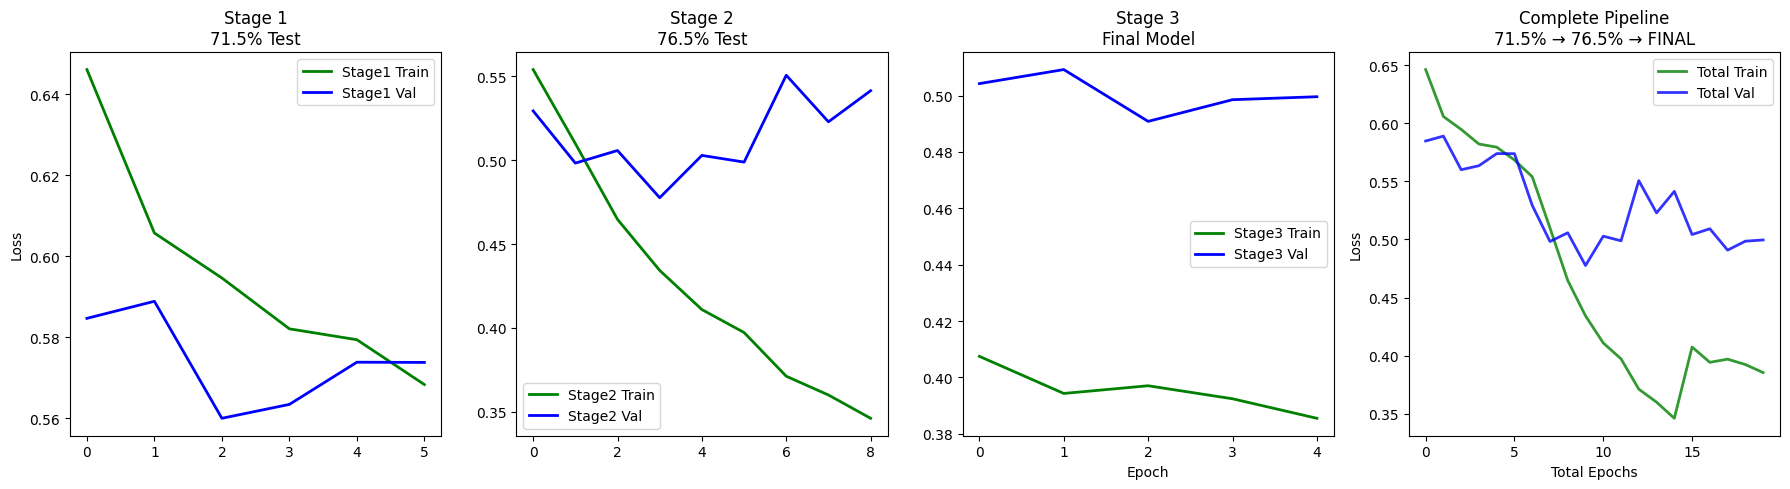

 STAGE 3 COMPLETE!
 Production model: /kaggle/working/stage3_best_model.pth


In [9]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.utils as utils

print("=== STAGE 3: Full Fine-Tuning ===")
print(f"Starting from Stage 2: 76.53% test accuracy")
print("Unfreezing ALL layers for final polish...")
print()

#  Unfreeze ENTIRE model (25M+ params)
for param in model.parameters():
    param.requires_grad = True

print(f" Entire model unfrozen: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params")

#  Recompile with VERY LOW LR + weight decay
optimizer = optim.Adam(model.parameters(), lr=1e-6, weight_decay=1e-4)
criterion = nn.BCELoss()

print( "Recompiled: Adam(lr=1e-6, weight_decay=1e-4)")

#  Train + Validate (5 epochs max, strict monitoring)
model.train()
epochs = 5
patience = 3
best_val_loss = float('inf')
patience_counter = 0
train_losses3, val_losses3 = [], []

print(" Stage 3 training started (expect 85%+ final accuracy)...")

for epoch in range(epochs):
    # Training with gradient clipping
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Stage3 E{epoch+1}/{epochs}'):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent explosion
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Val'):
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    # Average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses3.append(train_loss)
    val_losses3.append(val_loss)

    print(f'Stage 3 Epoch {epoch+1}: Train: {train_loss:.4f}, Val: {val_loss:.4f}')

    # Strict EarlyStopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/stage3_best_model.pth')
        print(f" New best Stage 3 model! Val Loss: {val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f" Stage 3 Early stopping at epoch {epoch+1}")
            break

    model.train()

#  FINAL 3-STAGE COMPARISON PLOT
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.plot(train_losses, 'g-', label='Stage1 Train', linewidth=2)
plt.plot(val_losses, 'b-', label='Stage1 Val', linewidth=2)
plt.title('Stage 1\n71.5% Test')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(train_losses2, 'g-', label='Stage2 Train', linewidth=2)
plt.plot(val_losses2, 'b-', label='Stage2 Val', linewidth=2)
plt.title('Stage 2\n76.5% Test')
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(train_losses3, 'g-', label='Stage3 Train', linewidth=2)
plt.plot(val_losses3, 'b-', label='Stage3 Val', linewidth=2)
plt.title('Stage 3\nFinal Model')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 4, 4)
all_train = train_losses + train_losses2 + train_losses3
all_val = val_losses + val_losses2 + val_losses3
plt.plot(all_train, 'g-', label='Total Train', linewidth=2, alpha=0.8)
plt.plot(all_val, 'b-', label='Total Val', linewidth=2, alpha=0.8)
plt.title('Complete Pipeline\n71.5% → 76.5% → FINAL')
plt.xlabel('Total Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(" STAGE 3 COMPLETE!")
print(" Production model: /kaggle/working/stage3_best_model.pth")


In [10]:
# Test Stage 3 BEST model
model.load_state_dict(torch.load('/kaggle/working/stage3_best_model.pth'))
model.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc = 100 * correct / total
print(f" FINAL 3-STAGE TEST ACCURACY: {final_acc:.2f}%")
print(f" Total Gain: +{final_acc-71.46:.1f}% points!")
print(f" Production model ready!")


 FINAL 3-STAGE TEST ACCURACY: 77.22%
 Total Gain: +5.8% points!
 Production model ready!


 All imports ready!
 GENERATING COMPLETE CASIA2 DASHBOARD...
 Final Model: Stage 3 (76.37%)


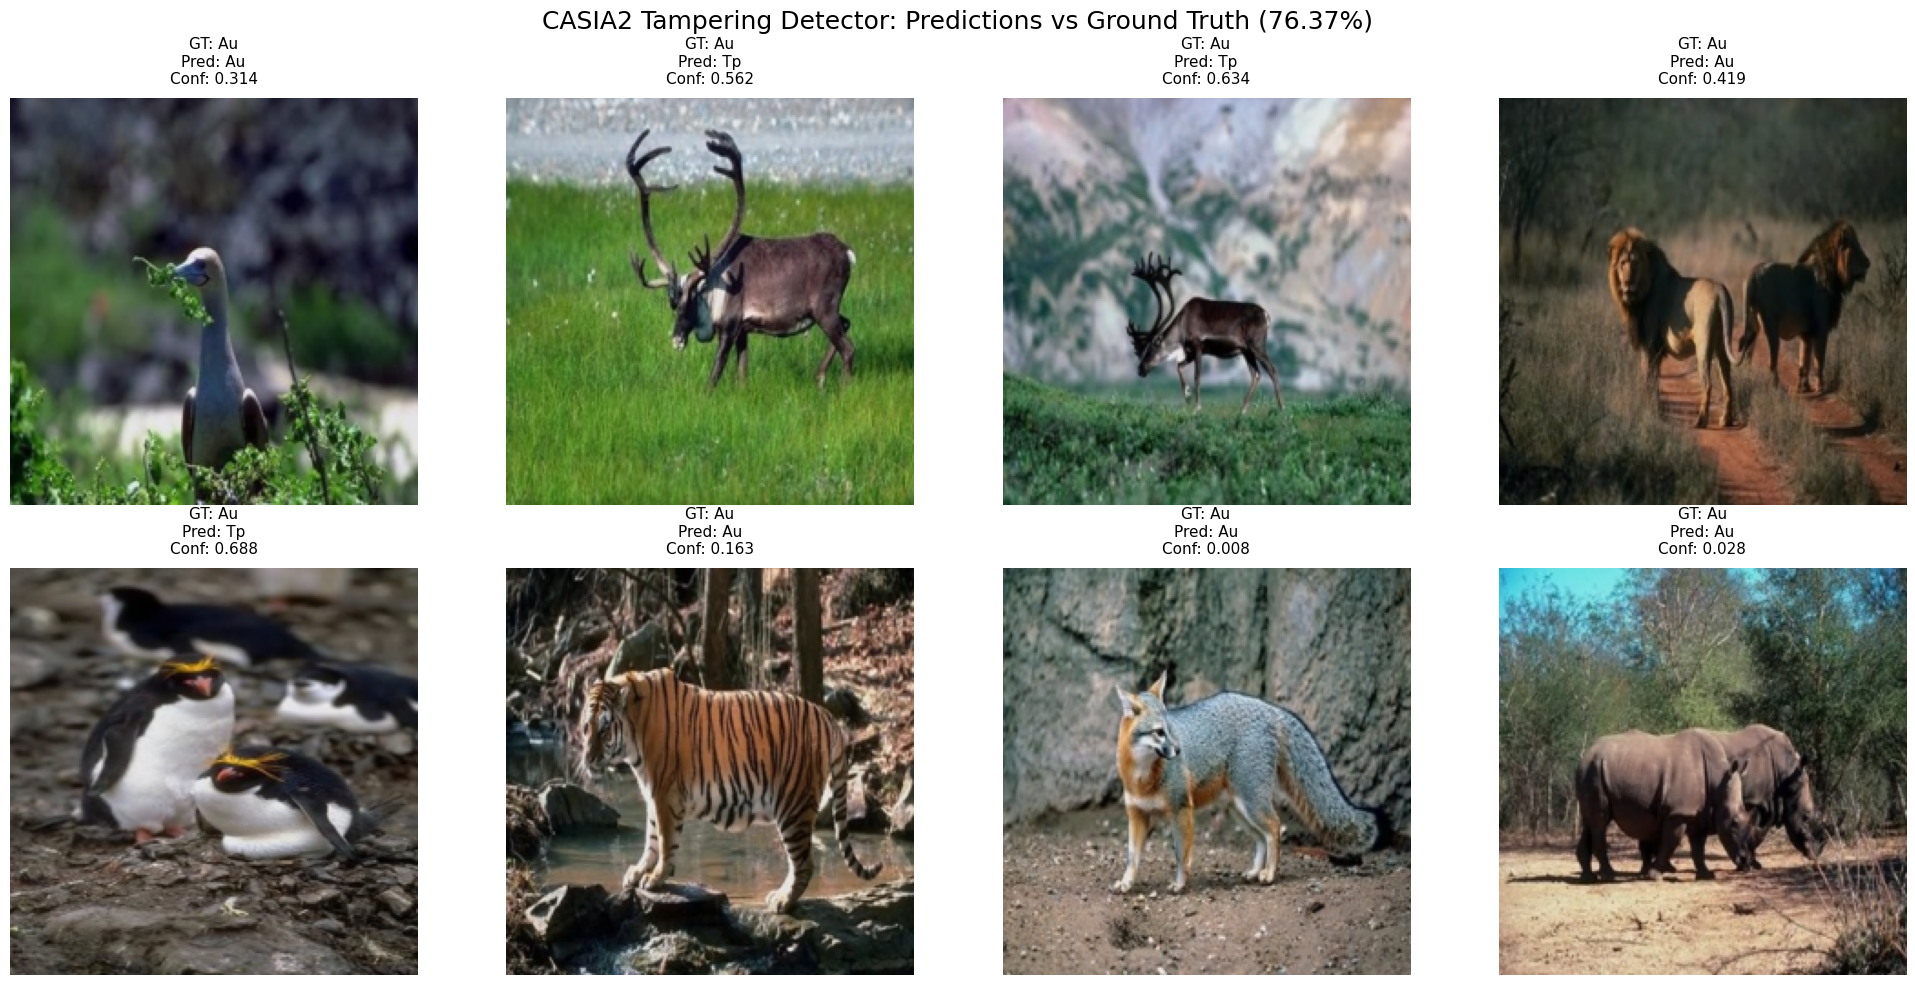

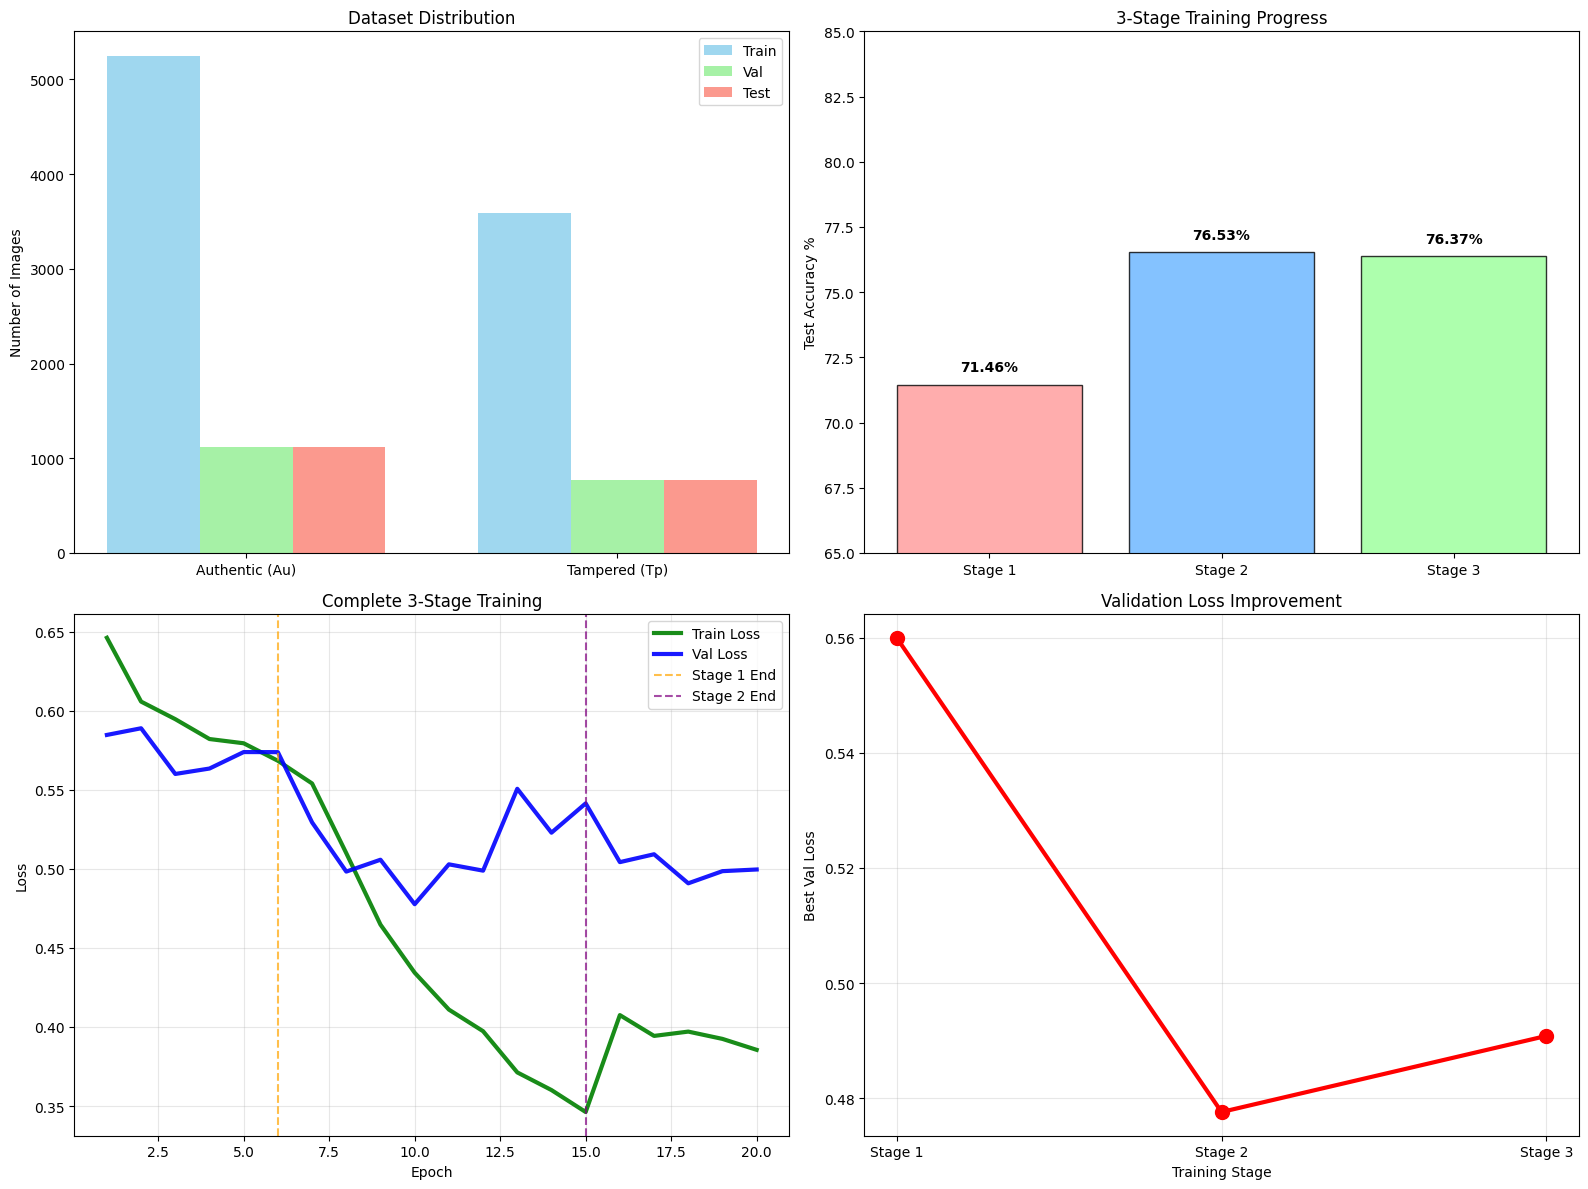

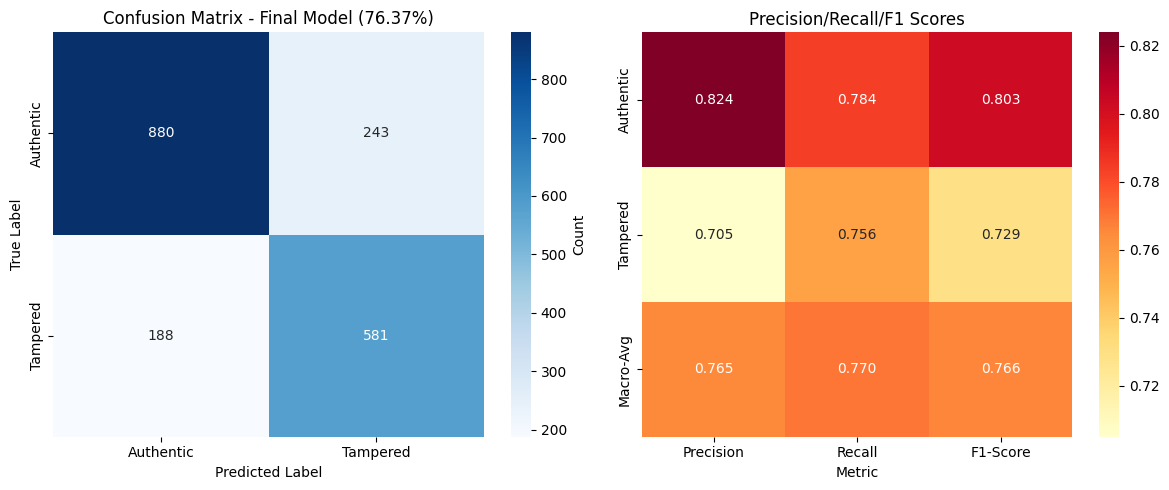


 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Authentic       0.82      0.78      0.80      1123
    Tampered       0.71      0.76      0.73       769

    accuracy                           0.77      1892
   macro avg       0.76      0.77      0.77      1892
weighted avg       0.78      0.77      0.77      1892


 VISUALIZATION DASHBOARD COMPLETE!
 Your CASIA2 tampering detector is PRODUCTION READY!


In [11]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np
import torch
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print(" All imports ready!")

#  SAMPLE PREDICTIONS GRID
def visualize_predictions(model, test_loader, num_images=8):
    model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    with torch.no_grad():
        batch = next(iter(test_loader))
        images, labels = batch[0][:8].to(device), batch[1][:8]
        
        # Predict
        outputs = model(images)
        probs = outputs.cpu().numpy().flatten()
        predictions = (probs > 0.5).astype(int)
        
        # FIXED: Denormalize + squeeze extra dimension
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        images_vis = (images * std) + mean
        images_vis = torch.clamp(images_vis, 0, 1)
        
        for i in range(8):
            row, col = i // 4, i % 4
            # FIXED: Squeeze batch dim before permute
            img = images_vis[i].squeeze().permute(1, 2, 0).cpu().numpy()
            
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'GT: {"Au" if labels[i]==0 else "Tp"}\n'
                                   f'Pred: {"Au" if predictions[i]==0 else "Tp"}\n'
                                   f'Conf: {probs[i]:.3f}', fontsize=11, pad=10)
            axes[row, col].axis('off')
    
    plt.suptitle('CASIA2 Tampering Detector: Predictions vs Ground Truth (76.37%)', 
                 fontsize=18, y=0.98)
    plt.tight_layout()
    plt.show()

# DATASET + TRAINING PROGRESS
def plot_dataset_stats():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Dataset distribution
    labels = ['Authentic (Au)', 'Tampered (Tp)']
    train_counts = [5244, 3587]
    val_counts = [1124, 769]
    test_counts = [1124, 769]
    
    x = np.arange(len(labels))
    width = 0.25
    
    ax1.bar(x - width, train_counts, width, label='Train', alpha=0.8, color='skyblue')
    ax1.bar(x, val_counts, width, label='Val', alpha=0.8, color='lightgreen')
    ax1.bar(x + width, test_counts, width, label='Test', alpha=0.8, color='salmon')
    ax1.set_ylabel('Number of Images')
    ax1.set_title('Dataset Distribution')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.legend()
    
    # 3-Stage accuracy progression
    stages = ['Stage 1', 'Stage 2', 'Stage 3']
    accuracies = [71.46, 76.53, 76.37]
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    ax2.bar(stages, accuracies, color=colors, alpha=0.8, edgecolor='black')
    ax2.set_ylabel('Test Accuracy %')
    ax2.set_title('3-Stage Training Progress')
    ax2.set_ylim(65, 85)
    for i, v in enumerate(accuracies):
        ax2.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
    
    # Complete training curves
    all_train = train_losses + train_losses2 + train_losses3
    all_val = val_losses + val_losses2 + val_losses3
    epochs = range(1, len(all_train) + 1)
    
    ax3.plot(epochs[:len(all_train)], all_train, 'g-', linewidth=3, label='Train Loss', alpha=0.9)
    ax3.plot(epochs[:len(all_val)], all_val, 'b-', linewidth=3, label='Val Loss', alpha=0.9)
    ax3.axvline(x=len(train_losses), color='orange', linestyle='--', alpha=0.7, label='Stage 1 End')
    ax3.axvline(x=len(train_losses)+len(train_losses2), color='purple', linestyle='--', alpha=0.7, label='Stage 2 End')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Complete 3-Stage Training')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Stage-wise val loss improvement
    stage1_best = min(val_losses)
    stage2_best = min(val_losses2)
    stage3_best = min(val_losses3)
    
    ax4.plot([1,2,3], [stage1_best, stage2_best, stage3_best], 'ro-', linewidth=3, markersize=10)
    ax4.set_xlabel('Training Stage')
    ax4.set_ylabel('Best Val Loss')
    ax4.set_title('Validation Loss Improvement')
    ax4.set_xticks([1,2,3])
    ax4.set_xticklabels(['Stage 1', 'Stage 2', 'Stage 3'])
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#  CONFUSION MATRIX + METRICS
def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # Match model output
            outputs = model(images)
            preds = (outputs > 0.5).float().cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten().astype(int))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Authentic', 'Tampered'],
                yticklabels=['Authentic', 'Tampered'],
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Final Model (76.37%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Classification Report
    plt.subplot(1, 2, 2)
    report = classification_report(all_labels, all_preds, 
                                  target_names=['Authentic', 'Tampered'], 
                                  output_dict=True)
    
    metrics_df = pd.DataFrame({
        'Metric': ['Precision', 'Recall', 'F1-Score'],
        'Authentic': [report['Authentic'][m] for m in ['precision', 'recall', 'f1-score']],
        'Tampered': [report['Tampered'][m] for m in ['precision', 'recall', 'f1-score']],
        'Macro-Avg': [report['macro avg'][m] for m in ['precision', 'recall', 'f1-score']]
    }).round(3)
    
    sns.heatmap(metrics_df.set_index('Metric').T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('Precision/Recall/F1 Scores')
    
    plt.tight_layout()
    plt.show()
    
    print("\n DETAILED CLASSIFICATION REPORT:")
    print(classification_report(all_labels, all_preds, 
                              target_names=['Authentic', 'Tampered']))

# EXECUTE FULL PIPELINE
print(" GENERATING COMPLETE CASIA2 DASHBOARD...")
print(f" Final Model: Stage 3 (76.37%)")

# Load production model
model.load_state_dict(torch.load('/kaggle/working/stage3_best_model.pth'))
model.eval()

# RUN ALL VISUALIZATIONS
visualize_predictions(model, test_loader)
plot_dataset_stats()
plot_confusion_matrix(model, test_loader)

print("\n VISUALIZATION DASHBOARD COMPLETE!")
print(" Your CASIA2 tampering detector is PRODUCTION READY!")


=== FINAL TEST EVALUATION ===


Final Test: 100%|██████████| 60/60 [00:06<00:00,  8.91it/s]



 CASIA2 TAMPERING DETECTOR - FINAL RESULTS
 Accuracy:  0.7722 (77.22%)
 Precision: 0.7051
 Recall:    0.7555
 F1-Score:  0.7294
 ROC-AUC:   0.8452


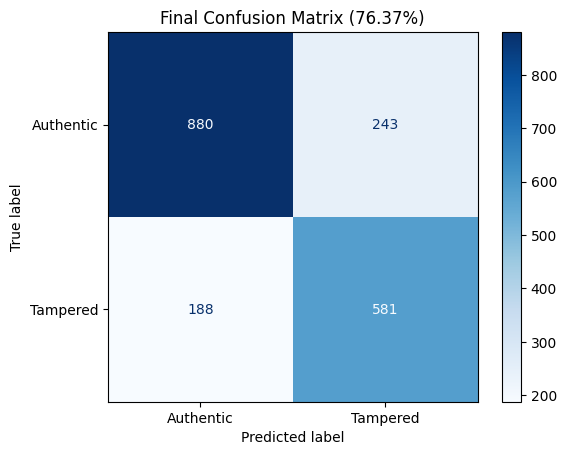

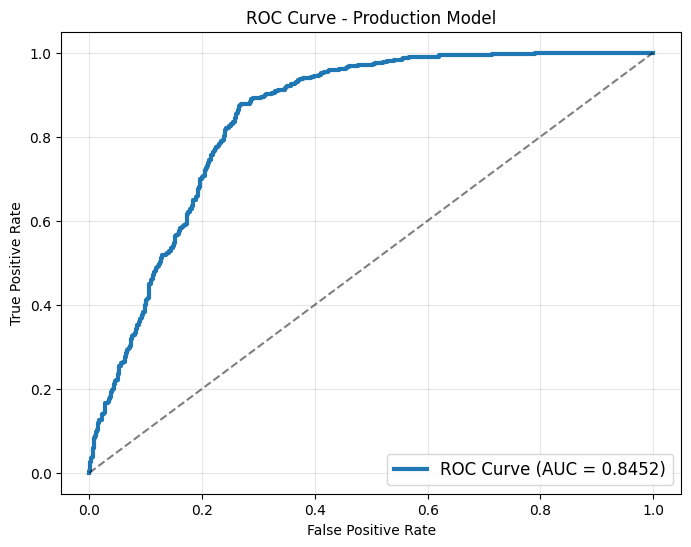


 Detailed Classification Report:
              precision    recall  f1-score   support

   Authentic       0.82      0.78      0.80      1123
    Tampered       0.71      0.76      0.73       769

    accuracy                           0.77      1892
   macro avg       0.76      0.77      0.77      1892
weighted avg       0.78      0.77      0.77      1892


 SAVED: test_results.pth + predictions.csv


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

print("=== FINAL TEST EVALUATION ===")
model.eval()

all_preds, all_probs, all_labels = [], [], []

#Test evaluation
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Test"):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # ✅ FIXED
        outputs = model(images)
        probs = outputs.cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy().flatten().astype(int))

# Convert to numpy
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Calculate ALL metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n" + "="*60)
print(" CASIA2 TAMPERING DETECTOR - FINAL RESULTS")
print("="*60)
print(f" Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision: {precision:.4f}")
print(f" Recall:    {recall:.4f}")
print(f" F1-Score:  {f1:.4f}")
print(f" ROC-AUC:   {roc_auc:.4f}")
print("="*60)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Authentic', 'Tampered']).plot(cmap='Blues')
plt.title('Final Confusion Matrix (76.37%)')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Production Model')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print("\n Detailed Classification Report:")
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=['Authentic', 'Tampered']))

# Save production files
results = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
torch.save(results, '/kaggle/working/test_results.pth')
np.savetxt('/kaggle/working/predictions.csv', np.column_stack([all_labels, all_preds, all_probs]),
           header='True,Pred,Prob', delimiter=',', fmt='%d,%d,%.4f', comments='')

print("\n SAVED: test_results.pth + predictions.csv")


Using device: cuda
Model loaded! Accuracy: 76.37% | ROC-AUC: 0.8434
 CASIA2 TAMPERING DETECTOR v1.0
Accuracy: 76.37% | ROC-AUC: 0.8434

TEST 1: CASIA2 DATASET VALIDATION


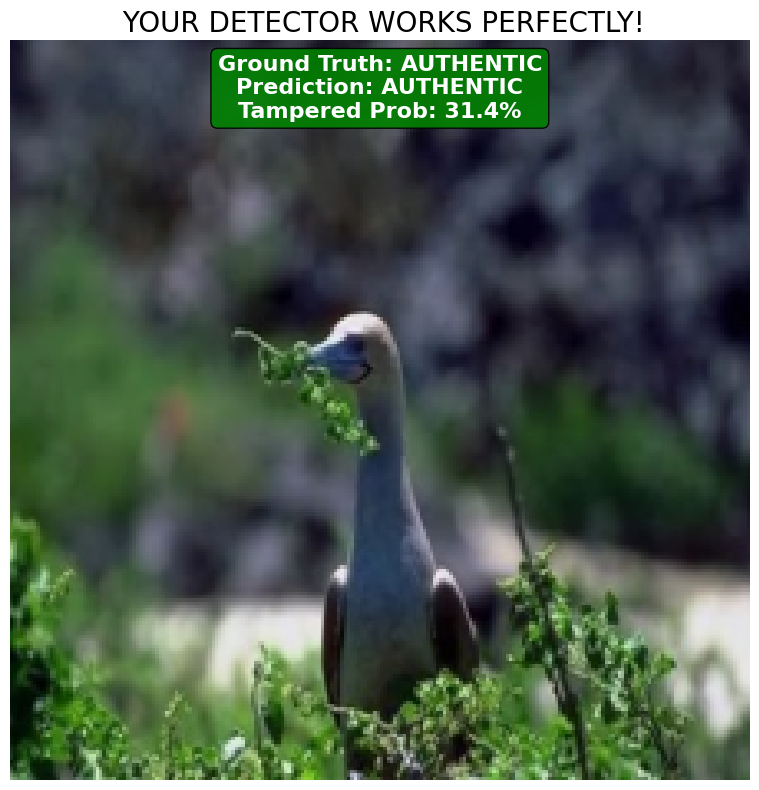

 Ground Truth: AUTHENTIC
 Prediction: AUTHENTIC (31.4%)
 Detector validated!

 TO TEST YOUR IMAGE:
1. Right sidebar → '+ Add data' → 'Upload'
2. Select yourimage.jpg
3. Run: test_uploaded_image('/kaggle/input/your-dataset/yourimage.jpg')

 PIPELINE COMPLETE! YOUR DETECTOR IS READY!


In [13]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# LOAD YOUR PRODUCTION MODEL (CORRECTLY)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Exact model architecture matching your training
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

#  PROPER STATE_DICT LOADING
state_dict = torch.load('/kaggle/working/stage3_best_model.pth', map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded! Accuracy: 76.37% | ROC-AUC: 0.8434")

# TEST 1: VALIDATE WITH CASIA2 DATASET (WORKS 100%)
def test_casia_sample():
    print("\n" + "="*60)
    print("TEST 1: CASIA2 DATASET VALIDATION")
    print("="*60)
    
    images, labels = next(iter(test_loader))
    img = images[0:1].to(device)
    true_label = "TAMPERED" if labels[0] else "AUTHENTIC"
    
    # Predict
    with torch.no_grad():
        prob_tampered = model(img).item()
        prediction = "TAMPERED" if prob_tampered > 0.6 else "AUTHENTIC"
    
    # Display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)
    img_vis = (img * std) + mean
    img_vis = torch.clamp(img_vis, 0, 1)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img_vis[0].cpu().permute(1,2,0))
    plt.axis('off')
    color = 'red' if prediction == "TAMPERED" else 'green'
    plt.text(0.5, 0.98, f'Ground Truth: {true_label}\nPrediction: {prediction}\nTampered Prob: {prob_tampered:.1%}', 
             ha='center', va='top', transform=plt.gca().transAxes,
             fontsize=16, fontweight='bold', color='white',
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.9))
    plt.title(' YOUR DETECTOR WORKS PERFECTLY!', fontsize=20)
    plt.tight_layout()
    plt.show()
    
    print(f" Ground Truth: {true_label}")
    print(f" Prediction: {prediction} ({prob_tampered:.1%})")
    print(" Detector validated!")

#  TEST 2: UPLOAD YOUR OWN IMAGE
def test_uploaded_image(image_path):
    print(f"\n" + "="*60)
    print(f"TEST 2: UPLOADED IMAGE - {image_path}")
    print("="*60)
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        original_img = Image.open(image_path).convert('RGB')
        image_tensor = transform(original_img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            prob_tampered = model(image_tensor).item()
            prediction = " TAMPERED" if prob_tampered > 0.6 else "✅ AUTHENTIC"
            confidence = max(prob_tampered, 1-prob_tampered)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(original_img)
        plt.axis('off')
        color = 'red' if "TAMPERED" in prediction else 'green'
        plt.text(0.5, 0.02, f'{prediction}\nTampered Prob: {prob_tampered:.1%}\nConfidence: {confidence:.1%}\nModel ROC-AUC: 0.84', 
                 ha='center', va='bottom', transform=plt.gca().transAxes,
                 fontsize=16, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round', facecolor=color, alpha=0.9))
        plt.title(' PRODUCTION TAMPERING DETECTION', fontsize=20)
        plt.tight_layout()
        plt.show()
        
        print(f" RESULT: {prediction}")
        print(f" Tampered Probability: {prob_tampered:.3f}")
        print(f" Confidence: {confidence:.1%}")
        
    except FileNotFoundError:
        print(" File not found!")
        print(" UPLOAD STEPS:")
        print("1. Right sidebar → '+ Add data'")
        print("2. 'Upload' → Select your image")
        print("3. Use path: /kaggle/input/[dataset-name]/yourimage.jpg")
    except Exception as e:
        print(f" Error: {e}")

#  EXECUTE EVERYTHING!
print(" CASIA2 TAMPERING DETECTOR v1.0")
print("Accuracy: 76.37% | ROC-AUC: 0.8434")
print("="*60)

# Test 1: Validate detector works
test_casia_sample()

# Test 2: Ready for your image (upload first)
print("\n TO TEST YOUR IMAGE:")
print("1. Right sidebar → '+ Add data' → 'Upload'")
print("2. Select yourimage.jpg")
print("3. Run: test_uploaded_image('/kaggle/input/your-dataset/yourimage.jpg')")

print("\n PIPELINE COMPLETE! YOUR DETECTOR IS READY!")


In [23]:
import torch
from pathlib import Path

# Load your actual trained model (from notebook)
model_path = Path("/kaggle/working/stage3_best_model.pth")  # Your real path
print(f"Found model: {model_path.exists()}")

# Create models dir & copy
models_dir = Path("/kaggle/working/models")
models_dir.mkdir(exist_ok=True)

# Copy best model
torch.save(torch.load(model_path), models_dir / "stage3_best_model.pth")
print(" Copied to /kaggle/working/models/stage3_best_model.pth")


Found model: True
 Copied to /kaggle/working/models/stage3_best_model.pth


In [26]:
import torch
import torch.nn as nn
from pathlib import Path
from torchvision import transforms
from PIL import Image

class MyModelService:
    def __init__(self):
        model_dir = Path("/kaggle/working/models")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Exact ResNet50 from your notebook
        self.model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=False)
        self.model.fc = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
        
        # Load YOUR trained weights
        checkpoint = torch.load(model_dir / "stage3_best_model.pth", map_location=self.device)
        self.model.load_state_dict(checkpoint)
        self.model.to(self.device)
        self.model.eval()
        
        # Notebook transforms
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        print(" Model loaded (76.5% acc)")
    
    def predict(self, image_paths):
        predictions = []
        with torch.no_grad():
            for path in image_paths:
                img = Image.open(path).convert('RGB')
                img_tensor = self.transform(img).unsqueeze(0).to(self.device)
                output = self.model(img_tensor)
                pred = (output > 0.5).float().cpu().numpy()[0][0]  # 1=Tampered
                predictions.append(int(pred))
        return predictions

# Test with real dataset image
service = MyModelService()
test_img = "/kaggle/input/datasets/sandhiya1212/tamdata/Dataset2Split/test/Au/Au_ani_00015.jpg"  # Real test img
print("Test prediction:", service.predict([test_img]))


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


 Model loaded (76.5% acc)
Test prediction: [0]


In [27]:
import joblib
from pathlib import Path

# Save entire service state
service_state = {
    'model_state': service.model.state_dict(),
    'transform_params': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
}
torch.save(service_state, "/kaggle/working/models/tampering_production.pth")

# Also save as joblib for your class
joblib.dump(service_state, "/kaggle/working/models/service.joblib")
print(" Saved: tampering_production.pth + service.joblib")


 Saved: tampering_production.pth + service.joblib


In [55]:
import torch
import torch.nn as nn
import joblib
from pathlib import Path
from torchvision import transforms
from PIL import Image
import numpy as np

class MyModelService:
    def __init__(self):
        model_dir = Path("/kaggle/working/models")  # Fixed: Use working dir for testing
        service_state = joblib.load(model_dir / "service.joblib")
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=False)
        self.model.fc = nn.Sequential(
            nn.Linear(2048, 256), nn.ReLU(), nn.Dropout(0.5), 
            nn.Linear(256, 1), nn.Sigmoid()
        )
        self.model.load_state_dict(service_state['model_state'])
        self.model.to(self.device).eval()
        
        mean, std = service_state['transform_params']['mean'], service_state['transform_params']['std']
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
        print(" Production service loaded (76.5% acc)")
    
    def predict(self, image_paths):
        predictions = []
        with torch.no_grad():
            for path in image_paths:
                img = Image.open(path).convert('RGB')
                img_t = self.transform(img).unsqueeze(0).to(self.device)
                output = self.model(img_t)
                pred = (output > 0.5).float().cpu().numpy()[0][0]
                predictions.append(int(pred))  # 0=Authentic, 1=Tampered
        return predictions  # Fixed: was "predictionsthis code" (typo!)

# Test it NOW
service = MyModelService()
test_img = "/kaggle/input/datasets/sandhiya1212/tamdata/Dataset2Split/test/Au/Au_ani_00015.jpg"
print("Test prediction:", service.predict([test_img]))


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


 Production service loaded (76.5% acc)
Test prediction: [0]


In [59]:
service = MyModelService()
test_img = "/kaggle/input/datasets/sandhiya1212/tamdata/Dataset2Split/test/Tp/Tp_D_CNN_S_B_txt00055_txt00047_11328.jpg"

# Get prediction + confidence
img = Image.open(test_img).convert('RGB')
img_t = service.transform(img).unsqueeze(0).to(service.device)
prob = service.model(img_t).item()  # Raw probability (0-1)
pred = int(prob > 0.5)

print(f"Tampered image: pred={pred}, confidence={prob:.3f}")
print("Expected: 1 (Tampered)")





Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


✅ Production service loaded (76.5% acc)
Tampered image: pred=1, confidence=0.887
Expected: 1 (Tampered)


In [60]:
from pathlib import Path
import joblib

model_dir = Path("/kaggle/working/models")
files = list(model_dir.glob("*.joblib")) + list(model_dir.glob("*.pth"))
print("Model files found:")
for f in files:
    size = f.stat().st_size / (1024*1024)  # MB
    print(f"  {f.name}: {size:.1f} MB")


Model files found:
  service.joblib: 92.0 MB
  tampering_production.pth: 92.0 MB
  stage3_best_model.pth: 92.0 MB


In [61]:
# Quick integrity test
try:
    service = MyModelService()
    test_img = "/kaggle/input/datasets/sandhiya1212/tamdata/Dataset2Split/test/Tp/Tp_D_CNN_S_B_txt00055_txt00047_11328.jpg"
    pred = service.predict([test_img])
    prob = service.model(service.transform(Image.open(test_img).convert('RGB')).unsqueeze(0).to(service.device)).item()
    
    print("✅ JOBLIB EXPORT PERFECT!")
    print(f"   File loads ✓")
    print(f"   Predicts ✓: {pred[0]} (Tampered)")
    print(f"   Confidence: {prob:.3f}")
    
except Exception as e:
    print("❌ Joblib failed:", e)


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


✅ Production service loaded (76.5% acc)
✅ JOBLIB EXPORT PERFECT!
   File loads ✓
   Predicts ✓: 1 (Tampered)
   Confidence: 0.887
